<a href="https://colab.research.google.com/github/Aryangajbhare2002/Unified-/blob/main/Project%20Ultimate%20Music%20Atlantic%20USA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.6 MB/s eta 0:00:00


In [ ]:
Data=pd.read_csv('/content/Atlantic_United_States.csv')
Data.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [ ]:
# Calculate the number of unique songs per artist
unique_songs_per_artist = Data.groupby('artist')['song'].nunique().sort_values(ascending=False).reset_index()
unique_songs_per_artist.columns = ['artist', 'unique_song_count']

# Display the top 10 artists with the most unique songs
display(unique_songs_per_artist.head(10))

,artist,unique_song_count
0,Taylor Swift,96
1,Lil Uzi Vert,35
2,Zach Bryan,35
3,Drake,35
4,Travis Scott,31
5,Post Malone,27
6,Beyoncé,25
7,Bad Bunny,22
8,Kendrick Lamar,20
9,Future & Metro Boomin,19


In [ ]:
# Identify duplicate rows based on all columns
duplicate_entries = Data[Data.duplicated()]

# Count and display duplicates
print(f"Number of duplicate rows found: {len(duplicate_entries)}")
if not duplicate_entries.empty:
    display(duplicate_entries.head())

Number of duplicate rows found: 10


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
14400,01-03-2025,1,CARNIVAL,¥$ & Kanye West & Ty Dolla $ign,94,264324,album,16,True,https://i.scdn.co/image/ab67616d0000b2730a31b4...
14404,01-03-2025,5,Stick Season,Noah Kahan,98,182346,album,14,False,https://i.scdn.co/image/ab67616d0000b2736ee350...
14408,01-03-2025,9,Whatever She Wants,Bryson Tiller,85,161342,single,1,True,https://i.scdn.co/image/ab67616d0000b2731aba7b...
14409,01-03-2025,10,Lose Control,Teddy Swims,94,210688,album,10,False,https://i.scdn.co/image/ab67616d0000b2731a0323...
14410,01-03-2025,11,Lovin On Me,Jack Harlow,98,138411,single,1,True,https://i.scdn.co/image/ab67616d0000b273fcf4ad...


In [ ]:
# Calculate total duration per artist
artist_duration = Data.groupby('artist')['duration_ms'].sum().sort_values(ascending=False).reset_index()

# Add a rank column
artist_duration['rank'] = artist_duration['duration_ms'].rank(ascending=False, method='min').astype(int)

# Get the top 50
top_50_artists = artist_duration.head(50)

# Display the top 50 artists by total duration
print("Top 50 Artists by Total Playback Duration:")
display(top_50_artists)

Top 50 Artists by Total Playback Duration:


,artist,duration_ms,rank
0,Taylor Swift,454943346,1
1,Zach Bryan,393580532,2
2,Morgan Wallen,289274476,3
3,Drake,218990703,4
4,Sabrina Carpenter,176070365,5
5,Travis Scott,173300373,6
6,Billie Eilish,173298099,7
7,Chappell Roan,170864096,8
8,"Tyler, The Creator",140098646,9
9,SZA,117476982,10


In [ ]:
import plotly.express as px

# Sort by duration and get the top N artists (e.g., top 20 for better visualization)
top_artists_duration = artist_duration.head(20)

# Create a bar chart
fig = px.bar(
    top_artists_duration,
    x='artist',
    y='duration_ms',
    title='Top 20 Artists by Total Playback Duration',
    labels={'duration_ms': 'Total Duration (milliseconds)', 'artist': 'Artist'},
    color='artist' # Color bars by artist for distinction
)

fig.update_layout(xaxis_title='Artist', yaxis_title='Total Duration (milliseconds)')
fig.show()

The bar chart above displays the top 20 artists based on their total playback duration in milliseconds. Each bar represents an artist, and its height indicates the sum of `duration_ms` for all their songs. This visualization helps in quickly identifying the artists with the most accumulated playtime.

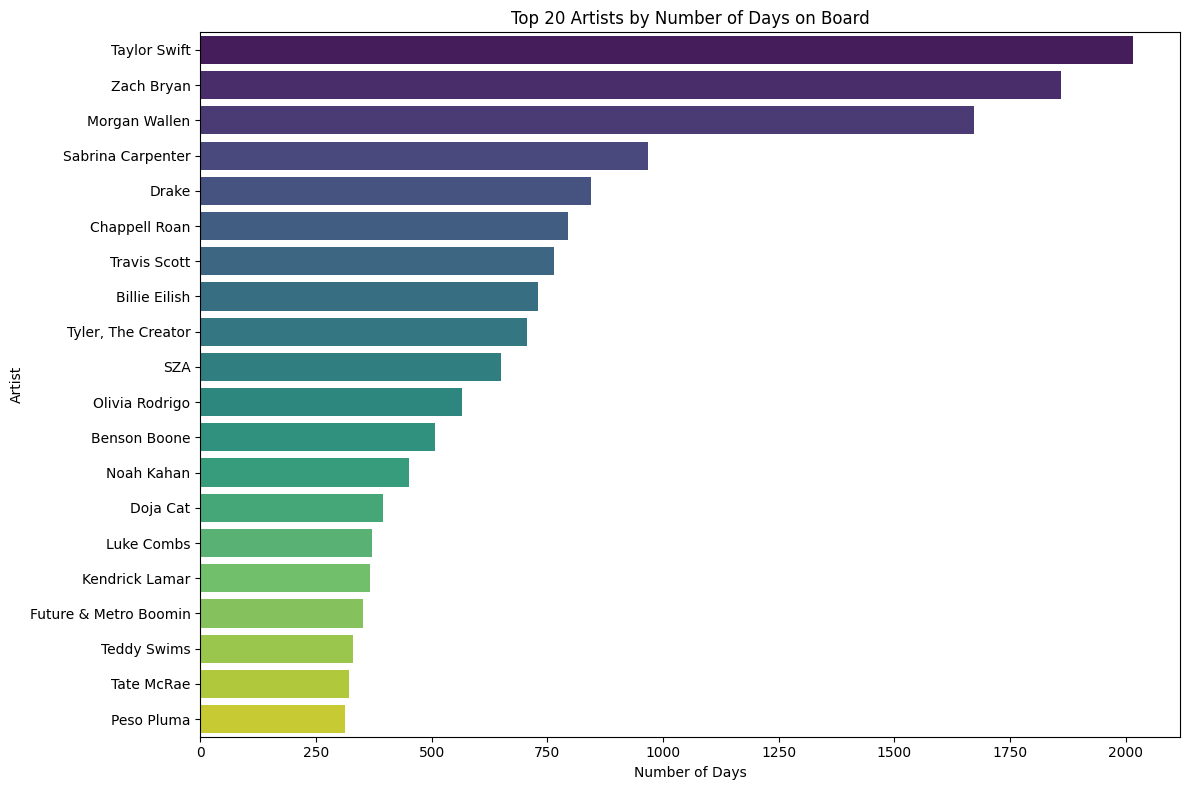

In [ ]:
# Count the number of occurrences (days) for each artist
artist_counts = Data['artist'].value_counts().reset_index()
artist_counts.columns = ['artist', 'days_on_board']

# Get top 20 for better visualization
top_20_on_board = artist_counts.head(20)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_on_board, x='days_on_board', y='artist', hue='artist', palette='viridis', legend=False)
plt.title('Top 20 Artists by Number of Days on Board')
plt.xlabel('Number of Days')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

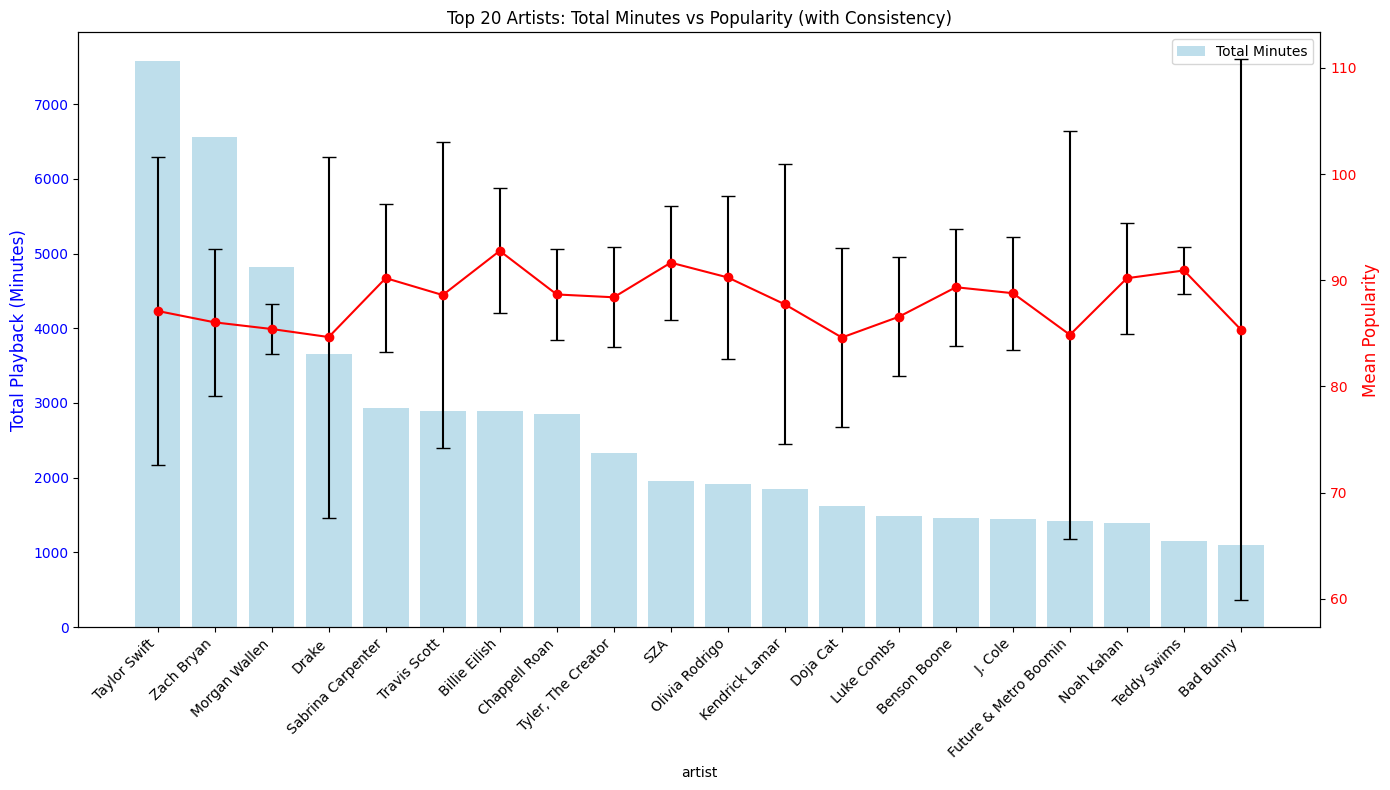

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics per artist
artist_stats = Data.groupby('artist').agg({
    'popularity': ['mean', 'std'],
    'duration_ms': 'sum'
}).reset_index()

# Flatten columns and rename
artist_stats.columns = ['artist', 'popularity_mean', 'popularity_std', 'total_duration_ms']

# Convert duration to minutes (1000 ms * 60 s)
artist_stats['total_minutes'] = artist_stats['total_duration_ms'] / (1000 * 60)

# Get top 20 artists by total minutes for clarity
top_artists_stats = artist_stats.sort_values(by='total_minutes', ascending=False).head(20)

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar plot for Total Minutes (Axis 1)
sns.barplot(data=top_artists_stats, x='artist', y='total_minutes', ax=ax1, color='skyblue', alpha=0.6, label='Total Minutes')
ax1.set_ylabel('Total Playback (Minutes)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Fix for UserWarning: set tick positions before labels
ax1.set_xticks(range(len(top_artists_stats['artist'])))
ax1.set_xticklabels(top_artists_stats['artist'], rotation=45, ha='right')

# Create a second axis for Popularity (Axis 2)
ax2 = ax1.twinx()

# Plot Popularity Mean with Error Bars for Std Dev
ax2.errorbar(x=top_artists_stats['artist'], y=top_artists_stats['popularity_mean'],
             yerr=top_artists_stats['popularity_std'].fillna(0), fmt='o-', color='red',
             ecolor='black', capsize=5, label='Avg Popularity (with Std Dev)')

ax2.set_ylabel('Mean Popularity', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Top 20 Artists: Total Minutes vs Popularity (with Consistency)')
fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Ensure date is in datetime format
Data['date'] = pd.to_datetime(Data['date'], dayfirst=True)

# Create a Quarter column (e.g., 2024Q1)
Data['quarter'] = Data['date'].dt.to_period('Q').astype(str)

# Group by quarter and artist to sum duration
quarterly_stats = Data.groupby(['quarter', 'artist'])['duration_ms'].sum().reset_index()

# Convert duration to minutes
quarterly_stats['duration_min'] = quarterly_stats['duration_ms'] / (1000 * 60)

# Rank artists within each quarter based on duration
quarterly_stats['rank'] = quarterly_stats.groupby('quarter')['duration_min'].rank(ascending=False, method='min').astype(int)

# Identify the top 10 artists overall to keep the plot readable
top_overall_artists = Data.groupby('artist')['duration_ms'].sum().nlargest(10).index
plot_data = quarterly_stats[quarterly_stats['artist'].isin(top_overall_artists)].sort_values('quarter')

# Using the previously calculated plot_data (Top 10 overall artists)
# We'll create an interactive Bump Chart

fig = px.line(
    plot_data,
    x='quarter',
    y='rank',
    color='artist',
    markers=True,
    title='Interactive Artist Rank by Playback Duration (Quarterly)',
    labels={'rank': 'Rank (1 is Top)', 'quarter': 'Quarter'},
    category_orders={'quarter': sorted(plot_data['quarter'].unique())}
)

# Invert the Y-axis so Rank 1 is at the top
fig.update_yaxes(autorange='reversed', tick0=1, dtick=1)

# Enhance layout
fig.update_layout(
    hovermode='closest',
    xaxis_title='Quarter',
    yaxis_title='Rank',
    legend_title='Artist',
    height=600
)

fig.show()

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Load data from the 'Data' variable in the kernel
# We assume 'Data' is already loaded in the environment
def load_data():
    df = Data.copy()
    if 'duration_min' not in df.columns:
        df['duration_min'] = df['duration_ms'] / (1000 * 60)
    return df

df = load_data()

st.title('Song Popularity vs. Duration Analysis')

# Sidebar filters
st.sidebar.header('Filters')

# Artist selection
all_artists = sorted(df['artist'].unique())
selected_artists = st.sidebar.multiselect('Select Artist(s)', options=all_artists, default=all_artists[:5])

# Album type selection
album_types = sorted(df['album_type'].unique())
selected_types = st.sidebar.multiselect('Select Album Type(s)', options=album_types, default=album_types)

# Filter data
filtered_df = df[df['artist'].isin(selected_artists) & df['album_type'].isin(selected_types)]

if not filtered_df.empty:
    fig = px.scatter(
        filtered_df,
        x='duration_min',
        y='popularity',
        color='artist',
        hover_data=['song', 'album_type'],
        title='Popularity vs. Duration (Minutes)',
        labels={'duration_min': 'Duration (Minutes)', 'popularity': 'Popularity Score'}
    )
    st.plotly_chart(fig, use_container_width=True)
    st.write(f'Showing {len(filtered_df)} entries')
else:
    st.warning('No data found for the selected filters.')

# Save the app to a file
with open('app.py', 'w') as f:
    f.write('''
import streamlit as st
import pandas as pd
import plotly.express as px

# In a real app, you would read the CSV
df = pd.read_csv('/content/Atlantic_United_States.csv')
df['duration_min'] = df['duration_ms'] / (1000 * 60)

st.title('Song Popularity vs. Duration Analysis')
st.sidebar.header('Filters')

selected_artists = st.sidebar.multiselect('Select Artist(s)', options=sorted(df['artist'].unique()), default=df['artist'].unique()[:5])
selected_types = st.sidebar.multiselect('Select Album Type(s)', options=sorted(df['album_type'].unique()), default=df['album_type'].unique())

filtered_df = df[df['artist'].isin(selected_artists) & df['album_type'].isin(selected_types)]

if not filtered_df.empty:
    fig = px.scatter(filtered_df, x='duration_min', y='popularity', color='artist', hover_data=['song'], title='Popularity vs. Duration')
    st.plotly_chart(fig, use_container_width=True)
else:
    st.warning('No data found.')
''')

2026-04-16 04:48:08.126 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.401 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-16 04:48:08.402 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.404 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 04:48:08.415 Thread 'MainThread': mi

In [ ]:
# Calculate total duration in minutes per album type
dom_data = Data.copy()
dom_data['duration_min'] = dom_data['duration_ms'] / (1000 * 60)
dominance_stats = dom_data.groupby('album_type')['duration_min'].sum().reset_index()

# Create a pie chart
fig = px.pie(
    dominance_stats,
    values='duration_min',
    names='album_type',
    title='Dominance of Song Types by Total Duration (Minutes)',
    hole=0.3,
    labels={'duration_min': 'Total Minutes', 'album_type': 'Song Type'}
)

fig.update_traces(textinfo='percent+label')
fig.show()

# Display the raw numbers for reference
display(dominance_stats.sort_values(by='duration_min', ascending=False))

,album_type,duration_min
0,album,66369.281733
2,single,25524.773817
1,compilation,140.541133


In [ ]:
# Identify the top artist by total duration
top_artist = Data.groupby('artist')['duration_ms'].sum().idxmax()
total_min = Data.groupby('artist')['duration_ms'].sum().max() / (1000 * 60)
print(f'The dominating artist is {top_artist} with {total_min:.2f} total minutes.')

# Updated Pie Chart with a different color palette
fig = px.pie(
    dominance_stats,
    values='duration_min',
    names='album_type',
    title=f'Dominance by Song Type (Top Artist: {top_artist})',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label')
fig.show()

The dominating artist is Taylor Swift with 7582.39 total minutes.


In [ ]:
import pandas as pd

# Prepare the data and write the full comprehensive dashboard app
with open('dashboard_app.py', 'w') as f:
  f.write('''
import streamlit as st
import pandas as pd
import plotly.express as px

# Load Data
@st.cache_data
def load_data():
    df = pd.read_csv('/content/Atlantic_United_States.csv')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df['duration_min'] = df['duration_ms'] / (1000 * 60)
    df['pop_per_min'] = df['popularity'] / df['duration_min']
    df['quarter'] = df['date'].dt.to_period('Q').astype(str)
    return df

df = load_data()

st.set_page_config(page_title="Ultimate Music Analytics", layout="wide")
st.title('🎵 Ultimate Music Playback & Popularity Dashboard')

# Sidebar Filters
st.sidebar.header('Global Filters')
all_artists = sorted(df['artist'].unique())
selected_artists = st.sidebar.multiselect('Select Artists for Trends/Scatter',
                                          options=all_artists,
                                          default=['Taylor Swift', 'Zach Bryan', 'Morgan Wallen', 'Drake', 'Sabrina Carpenter'])

# Row 1: Key Metrics
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("Total Playback (Hrs)", f"{df['duration_min'].sum() / 60:,.0f}")
with col2:
    st.metric("Unique Artists", len(all_artists))
with col3:
    top_artist = df.groupby('artist')['duration_ms'].sum().idxmax()
    st.metric("Top Artist (Duration)", top_artist)
with col4:
    st.metric("Total Entries", len(df))

# Row 2: Content Analysis
st.divider()
st.subheader("📦 Content & Explicit Analysis")
c1, c2 = st.columns(2)
with c1:
    dom_stats = df.groupby('album_type')['duration_min'].sum().reset_index()
    fig_pie = px.pie(dom_stats, values='duration_min', names='album_type', title='Dominance by Album Type', hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
    st.plotly_chart(fig_pie, use_container_width=True)
with c2:
    exp_stats = df.groupby('is_explicit')['duration_min'].sum().reset_index()
    exp_stats['Type'] = exp_stats['is_explicit'].map({True: 'Explicit', False: 'Non-Explicit'})
    fig_bar_exp = px.bar(exp_stats, x='Type', y='duration_min', color='Type', title='Explicit vs. Non-Explicit Playtime', color_discrete_map={'Explicit': '#ef553b', 'Non-Explicit': '#636efa'})
    st.plotly_chart(fig_bar_exp, use_container_width=True)

# Row 3: Advanced Popularity Metric
st.divider()
st.subheader("⚡ Efficiency: Popularity per Minute (Top 20 Artists)")
artist_ratio_stats = df.groupby('artist').agg({'pop_per_min': 'mean', 'position': 'mean', 'song': 'count'}).reset_index()
top_20_ratio = artist_ratio_stats.sort_values(by='pop_per_min', ascending=False).head(20)
fig_ratio = px.scatter(top_20_ratio, x='pop_per_min', y='position', size='song', color='artist', text='artist', title='Top 20: Popularity/Min Ratio vs. Avg Rank')
fig_ratio.update_yaxes(autorange='reversed')
st.plotly_chart(fig_ratio, use_container_width=True)

# Row 4: Quarterly Rankings (Bump Chart)
st.divider()
st.subheader("📈 Quarterly Artist Rankings")
quarterly_stats = df.groupby(['quarter', 'artist'])['duration_ms'].sum().reset_index()
quarterly_stats['rank'] = quarterly_stats.groupby('quarter')['duration_ms'].rank(ascending=False, method='min')
plot_data = quarterly_stats[quarterly_stats['artist'].isin(selected_artists)]
fig_bump = px.line(plot_data, x='quarter', y='rank', color='artist', markers=True, title='Artist Rank Trend (Selected Artists)')
fig_bump.update_yaxes(autorange='reversed')
st.plotly_chart(fig_bump, use_container_width=True)

# Row 5: Deep Dive Scatter
st.divider()
st.subheader("🔍 Song-Level Deep Dive")
filtered_df = df[df['artist'].isin(selected_artists)]
fig_scat = px.scatter(filtered_df, x='duration_min', y='popularity', color='artist', hover_data=['song'], title='Popularity vs. Duration for Selected Artists')
st.plotly_chart(fig_scat, use_container_width=True)
''')
print('Comprehensive dashboard script updated.')

Comprehensive dashboard script updated.


In [ ]:
import subprocess
import time

# Kill any existing streamlit processes to avoid port conflicts
subprocess.run(['pkill', 'streamlit'])

# Start the new dashboard
subprocess.Popen(['streamlit', 'run', 'dashboard_app.py', '--server.port', '8502'])

# Give it a moment to start
time.sleep(5)
print('Dashboard is starting... Click the link below to access it.')
!npx localtunnel --port 8502

Dashboard is starting... Click the link below to access it.
⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


### Troubleshooting LocalTunnel

First, let's kill any old Streamlit processes and restart the dashboard. Then, we'll try to establish the `localtunnel` connection again. Make sure to type `y` and press Enter if `localtunnel` prompts you for confirmation.

In [41]:
import subprocess
import time

# Kill any existing streamlit processes to avoid port conflicts
subprocess.run(['pkill', 'streamlit'])

# Start the new dashboard
# Ensure this matches the port used in your localtunnel command
subprocess.Popen(['streamlit', 'run', 'dashboard_app.py', '--server.port', '8502'])

# Give it a moment to start
time.sleep(5)
print('Dashboard is starting... Attempting localtunnel connection.')

# Run localtunnel. Be ready to type 'y' if prompted.
!npx localtunnel --port 8502

Dashboard is starting... Attempting localtunnel connection.
⠙⠹⠸⠼⠴⠦⠧your url is: https://every-mails-decide.loca.lt
y
^C


In [ ]:
# Group by is_explicit and sum duration_ms
explicit_stats = Data.groupby('is_explicit')['duration_ms'].sum().reset_index()

# Convert to minutes
explicit_stats['total_duration_min'] = explicit_stats['duration_ms'] / (1000 * 60)

# Map boolean to string for better labeling
explicit_stats['Content Type'] = explicit_stats['is_explicit'].map({True: 'Explicit', False: 'Non-Explicit'})

# Create bar plot
fig = px.bar(
    explicit_stats,
    x='Content Type',
    y='total_duration_min',
    color='Content Type',
    text_auto='.2s',
    title='Total Playback Duration: Explicit vs. Non-Explicit Songs',
    labels={'total_duration_min': 'Total Duration (Minutes)'},
    color_discrete_map={'Explicit': '#ef553b', 'Non-Explicit': '#636efa'}
)

fig.update_layout(showlegend=False)
fig.show()

# Display summary
display(explicit_stats[['Content Type', 'total_duration_min']])

,Content Type,total_duration_min
0,Non-Explicit,47313.461000
1,Explicit,44721.135683


In [ ]:
# Group by quarter and sum total duration
quarter_trends = Data.groupby('quarter')['duration_ms'].sum().reset_index()

# Convert to minutes for better scale
quarter_trends['total_duration_min'] = quarter_trends['duration_ms'] / (1000 * 60)

# Sort by quarter chronologically
quarter_trends = quarter_trends.sort_values('quarter')

# Create the line chart
fig = px.line(
    quarter_trends,
    x='quarter',
    y='total_duration_min',
    markers=True,
    title='Total Playback Duration Trend by Quarter',
    labels={'quarter': 'Quarter', 'total_duration_min': 'Total Duration (Minutes)'}
)

fig.update_layout(xaxis_type='category')
fig.show()

# Display the trend values
display(quarter_trends[['quarter', 'total_duration_min']])

,quarter,total_duration_min
0,2024Q2,7327.622750
1,2024Q3,15378.792017
2,2024Q4,15050.096967
3,2025Q1,14486.224267
4,2025Q2,15713.782867
5,2025Q3,14468.626200
6,2025Q4,9609.451617


In [ ]:
!npm install -g localtunnel
import subprocess
import time

# Start streamlit in background
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# Get public URL via localtunnel
time.sleep(5)
print('Click the link below to access your Streamlit App:')
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏Click the link below to access your Streamlit App:
⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://funny-mice-think.loca.lt
^C


In [ ]:
# Calculate popularity per minute
Data['duration_min'] = Data['duration_ms'] / (1000 * 60)
Data['pop_per_min'] = Data['popularity'] / Data['duration_min']

# Group by artist to get average ratio and average rank (position)
artist_ratio_stats = Data.groupby('artist').agg({
    'pop_per_min': 'mean',
    'position': 'mean',
    'song': 'count'
}).reset_index()

# Get top 20 artists by the new measure
top_20_ratio = artist_ratio_stats.sort_values(by='pop_per_min', ascending=False).head(20)

import plotly.express as px

fig = px.scatter(
    top_20_ratio,
    x='pop_per_min',
    y='position',
    size='song',
    color='artist',
    text='artist',
    title='Top 20 Artists: Popularity per Minute vs. Average Chart Rank',
    labels={
        'pop_per_min': 'Avg Popularity/Minute Ratio',
        'position': 'Average Chart Position (Rank)',
        'song': 'Total Appearances'
    }
)

# Invert Y-axis so rank 1 is at the top
fig.update_yaxes(autorange='reversed')
fig.update_traces(textposition='top center')

fig.show()

display(top_20_ratio)

,artist,pop_per_min,position,song
61,Dominic Fike,68.568663,47.500000,2
221,Richy Mitch & The Coal Miners,61.354680,43.196429,56
247,The Kid LAROI,60.028859,31.684564,149
155,Lil Mabu,58.774234,27.928571,14
187,Nicki Minaj & Ice Spice & Aqua,50.301384,18.750000,104
47,Chino Pacas,49.080179,43.062500,32
183,Nat King Cole,48.154730,27.923077,65
31,Brent Faiyaz,46.612427,43.388889,18
200,Paul Russell,45.696077,36.000000,1
57,Dean Martin,45.526565,17.111111,45


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=top_20_ratio)

https://docs.google.com/spreadsheets/d/1X0zV590xRLvPMbFfufhnYPChH8QARnxKXCHCKygEYHg/edit#gid=0


In [ ]:
view1, dwn1, _ = st.columns([0.5,0.45,0.45]) # Added a third variable for the third column
with view1:
    expander = st.expander("view data")
    expander.write(Data)
with dwn1:
    st.download_button("data", data=Data.to_csv().encode("utf-8"),
                       file_name="/content/Atlantic_United_States.csv", mime = "text/csv")
    st.divider()


2026-04-16 06:32:50.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 06:32:50.290 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar